In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("ptbxl_database.csv")  # Change the filename accordingly

# Display basic info
print(df.info())  # Check data types & missing values
print(df.head())  # Preview first 5 rows


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21799 entries, 0 to 21798
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21799 non-null  int64  
 1   patient_id                    21799 non-null  float64
 2   age                           21799 non-null  float64
 3   sex                           21799 non-null  int64  
 4   height                        6974 non-null   float64
 5   weight                        9421 non-null   float64
 6   nurse                         20326 non-null  float64
 7   site                          21782 non-null  float64
 8   device                        21799 non-null  object 
 9   recording_date                21799 non-null  object 
 10  report                        21799 non-null  object 
 11  scp_codes                     21799 non-null  object 
 12  heart_axis                    13331 non-null  object 
 13  i

C:\Users\Asus\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


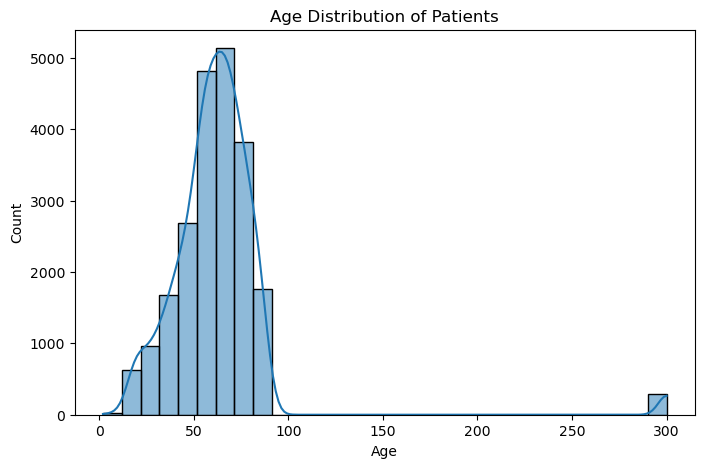

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


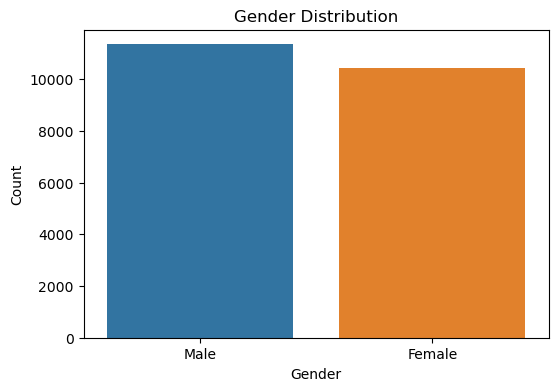

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['sex'])
plt.title('Gender Distribution')
plt.xticks([0, 1], ['Male', 'Female'])
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


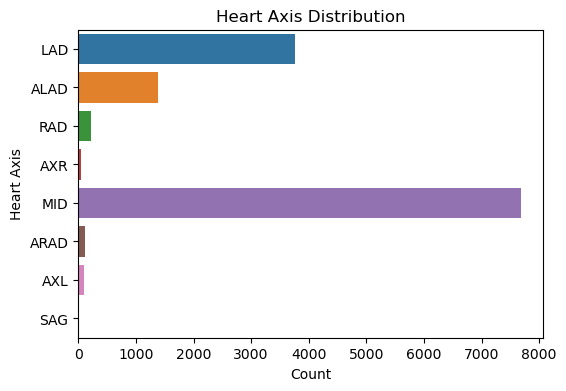

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(y=df['heart_axis'])
plt.title('Heart Axis Distribution')
plt.xlabel('Count')
plt.ylabel('Heart Axis')
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Select features & target
features = ['age', 'sex', 'height', 'weight', 'heart_axis']  # Use relevant features
X = df[features]
y = df['strat_fold']  # Assuming this is the binary target (modify as needed)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


ValueError: could not convert string to float: 'RAD'

In [10]:
print(df.dtypes)


ecg_id                            int64
patient_id                      float64
age                             float64
sex                               int64
height                          float64
weight                          float64
nurse                           float64
site                            float64
device                           object
recording_date                   object
report                           object
scp_codes                        object
heart_axis                       object
infarction_stadium1              object
infarction_stadium2              object
validated_by                    float64
second_opinion                     bool
initial_autogenerated_report       bool
validated_by_human                 bool
baseline_drift                   object
static_noise                     object
burst_noise                      object
electrodes_problems              object
extra_beats                      object
pacemaker                        object


In [11]:
df = df.drop(columns=['ecg_id', 'patient_id', 'recording_date', 'filename_lr', 'filename_hr', 'report', 'scp_codes'])


In [13]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'baseline_drift', 'static_noise',
              'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'device']

for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))  # Convert strings to numbers


In [14]:
print(df['site'].unique())
print(df['nurse'].unique())


[ 0.  3.  2.  1. 35. 16.  4. 39. 32. 17.  9. 10. 34. 44. 11. 30. 36. 13.
  5. 12. 38. 15. 25.  8. 14. 20. 29. 24. 21. 26.  6. 22. 18. 28. 45. 41.
 49. 40. 37. 27. 43.  7. 19. 48. 42. 33. 23. nan 46. 50. 47. 31.]
[ 2.  0. nan  1.  7.  8. 10.  5.  9. 11.  4.  3.  6.]


In [15]:
df = pd.get_dummies(df, columns=['site', 'nurse'], drop_first=True)


In [16]:
X = df.drop(columns=['strat_fold'])  # Features
y = df['strat_fold']  # Target

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [17]:
df = df.dropna()


In [18]:
df = df.fillna(df.mode().iloc[0])


In [21]:
print(df.dtypes)


age           float64
sex           float64
height        float64
weight        float64
device        float64
               ...   
nurse_7.0        bool
nurse_8.0        bool
nurse_9.0        bool
nurse_10.0       bool
nurse_11.0       bool
Length: 80, dtype: object


In [22]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Identify numerical columns
num_cols = df.select_dtypes(include=['float64']).columns

# Impute missing values with the mean
num_imputer = SimpleImputer(strategy='mean')  # Use "median" if the data is skewed
df[num_cols] = num_imputer.fit_transform(df[num_cols])

print(df.isnull().sum())  # Verify no NaN remains


age           0
sex           0
height        0
weight        0
device        0
             ..
nurse_7.0     0
nurse_8.0     0
nurse_9.0     0
nurse_10.0    0
nurse_11.0    0
Length: 80, dtype: int64


In [24]:
from sklearn.impute import SimpleImputer

# Impute numerical columns with mean
num_imputer = SimpleImputer(strategy='mean')
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns with most frequent value (only if they exist)
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Check if NaN values still exist
print(df.isnull().sum().sum(), "missing values remaining.")


0 missing values remaining.
